## LAB -10 Model Evaluation Metrics


First Five Records

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst a

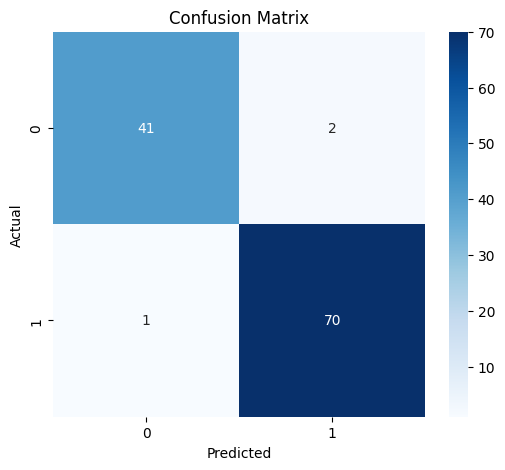

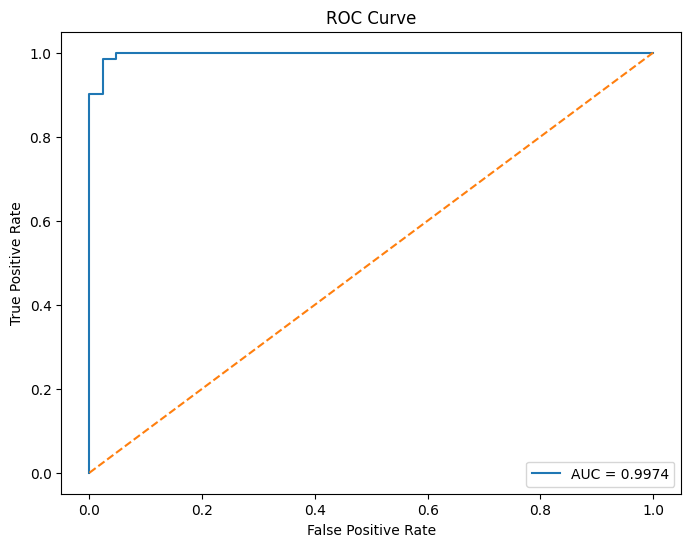

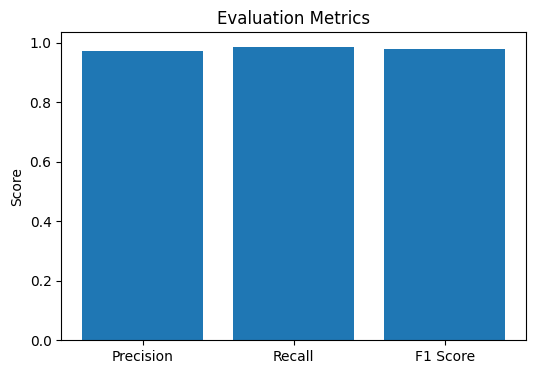


Prediction Result
Malignant Tumor

AUC Score = 0.99737962659679

Conclusion
Logistic Regression model was successfully evaluated using multiple evaluation metrics.
Accuracy, Precision, Recall, F1 Score, Confusion Matrix, ROC Curve and AUC Score were calculated.
The model achieved excellent classification performance on the Breast Cancer Dataset.


In [3]:
# ==========================================================
# Experiment 11 : Model Evaluation Metrics
# Dataset : Breast Cancer Dataset
# Algorithm : Logistic Regression
# ==========================================================

# Step 1 : Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# ==========================================================
# Step 2 : Load Dataset
# ==========================================================

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

# ==========================================================
# Step 3 : Create DataFrame
# ==========================================================

df = pd.DataFrame(
    X,
    columns=cancer.feature_names
)

df["Target"] = y

print("\nFirst Five Records\n")

print(df.head())

# ==========================================================
# Step 4 : Dataset Information
# ==========================================================

print("\nDataset Information\n")

print(df.info())

print("\nStatistical Summary\n")

print(df.describe())

# ==========================================================
# Step 5 : Check Missing Values
# ==========================================================

print("\nMissing Values\n")

print(df.isnull().sum())

# ==========================================================
# Step 6 : Separate Features and Target
# ==========================================================

X = df.iloc[:, :-1]

y = df.iloc[:, -1]

# ==========================================================
# Step 7 : Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# Step 8 : Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ==========================================================
# Step 9 : Build Model
# ==========================================================

model = LogisticRegression(
    max_iter=1000
)

# ==========================================================
# Step 10 : Train Model
# ==========================================================

model.fit(X_train, y_train)

# ==========================================================
# Step 11 : Predict Output
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# Step 12 : Training Accuracy
# ==========================================================

train_accuracy = model.score(
    X_train,
    y_train
)

print("\nTraining Accuracy =",
      train_accuracy)

# ==========================================================
# Step 13 : Testing Accuracy
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nTesting Accuracy =",
      accuracy)

# ==========================================================
# Step 14 : Precision
# ==========================================================

precision = precision_score(
    y_test,
    y_pred
)

print("\nPrecision =",
      precision)

# ==========================================================
# Step 15 : Recall
# ==========================================================

recall = recall_score(
    y_test,
    y_pred
)

print("\nRecall =",
      recall)

# ==========================================================
# Step 16 : F1 Score
# ==========================================================

f1 = f1_score(
    y_test,
    y_pred
)

print("\nF1 Score =",
      f1)

# ==========================================================
# Step 17 : Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix\n")

print(cm)

# ==========================================================
# Step 18 : Classification Report
# ==========================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================================
# Step 19 : Actual vs Predicted
# ==========================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted\n")

print(comparison.head(20))

# ==========================================================
# Step 20 : Confusion Matrix Heatmap
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ==========================================================
# Step 21 : ROC Curve
# ==========================================================

y_prob = model.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ==========================================================
# Step 22 : Precision Recall F1 Graph
# ==========================================================

metrics = [
    precision,
    recall,
    f1
]

names = [
    "Precision",
    "Recall",
    "F1 Score"
]

plt.figure(figsize=(6,4))

plt.bar(
    names,
    metrics
)

plt.title(
    "Evaluation Metrics"
)

plt.ylabel(
    "Score"
)

plt.show()

# ==========================================================
# Step 23 : Predict New Sample
# ==========================================================

sample = X.iloc[[0]]

sample = scaler.transform(
    sample
)

prediction = model.predict(
    sample
)

print("\nPrediction Result")

if prediction[0] == 0:
    print("Malignant Tumor")
else:
    print("Benign Tumor")

# ==========================================================
# Step 24 : Display AUC Score
# ==========================================================

print(
    "\nAUC Score =",
    auc_score
)

# ==========================================================
# Step 25 : Conclusion
# ==========================================================

print("\nConclusion")

print(
    "Logistic Regression model was successfully evaluated using multiple evaluation metrics."
)

print(
    "Accuracy, Precision, Recall, F1 Score, Confusion Matrix, ROC Curve and AUC Score were calculated."
)

print(
    "The model achieved excellent classification performance on the Breast Cancer Dataset."
)